In [ ]:
import time
start_time = time.time() #records current time

In [ ]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)

with open("/root/.kaggle/access_token", "w") as f:
    f.write("KGAT_8d6d7f01f2c1a6955f2ff163fc64d273")

os.chmod("/root/.kaggle/access_token", 0o600) #imports datasets from kaggle

In [ ]:
!pip install kaggle -q
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation
!unzip -q lgg-mri-segmentation.zip -d /content/lgg-mri-segmentation #library import and unzip dataset

Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
100% 714M/714M [00:41<00:00, 18.2MB/s]



In [ ]:
import os
print(os.listdir("/content/lgg-mri-segmentation")) #gives name

['kaggle_3m', 'lgg-mri-segmentation']


In [ ]:
import os

base_path = "/content/lgg-mri-segmentation/kaggle_3m"
patients = os.listdir(base_path)
print(f"Total patients: {len(patients)}")
print(f"Example patients: {patients[:5]}")

# look inside one patient folder
sample_patient = patients[0]
sample_files = os.listdir(os.path.join(base_path, sample_patient))
print(f"\nFiles for {sample_patient}:")
for f in sorted(sample_files):
    print(" ", f) #reads through files

Total patients: 112
Example patients: ['TCGA_DU_A5TP_19970614', 'TCGA_HT_8563_19981209', 'TCGA_DU_A5TS_19970726', 'TCGA_FG_5964_20010511', 'TCGA_CS_4942_19970222']

Files for TCGA_DU_A5TP_19970614:
  TCGA_DU_A5TP_19970614_1.tif
  TCGA_DU_A5TP_19970614_10.tif
  TCGA_DU_A5TP_19970614_10_mask.tif
  TCGA_DU_A5TP_19970614_11.tif
  TCGA_DU_A5TP_19970614_11_mask.tif
  TCGA_DU_A5TP_19970614_12.tif
  TCGA_DU_A5TP_19970614_12_mask.tif
  TCGA_DU_A5TP_19970614_13.tif
  TCGA_DU_A5TP_19970614_13_mask.tif
  TCGA_DU_A5TP_19970614_14.tif
  TCGA_DU_A5TP_19970614_14_mask.tif
  TCGA_DU_A5TP_19970614_15.tif
  TCGA_DU_A5TP_19970614_15_mask.tif
  TCGA_DU_A5TP_19970614_16.tif
  TCGA_DU_A5TP_19970614_16_mask.tif
  TCGA_DU_A5TP_19970614_17.tif
  TCGA_DU_A5TP_19970614_17_mask.tif
  TCGA_DU_A5TP_19970614_18.tif
  TCGA_DU_A5TP_19970614_18_mask.tif
  TCGA_DU_A5TP_19970614_19.tif
  TCGA_DU_A5TP_19970614_19_mask.tif
  TCGA_DU_A5TP_19970614_1_mask.tif
  TCGA_DU_A5TP_19970614_2.tif
  TCGA_DU_A5TP_19970614_20.tif
  TCGA

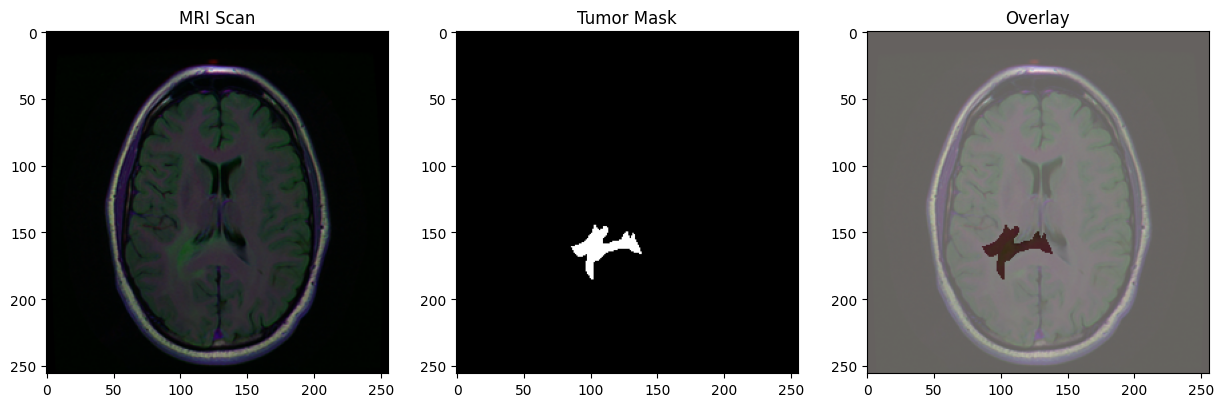

Patient: TCGA_DU_A5TP_19970614
Image shape: (256, 256, 3)
Mask unique values: [  0 255]


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# search across patients until we find a slice with tumor
for patient in patients:
    patient_path = os.path.join(base_path, patient)
    files = sorted(os.listdir(patient_path))
    mask_files = [f for f in files if "mask" in f]

    for mask_file in mask_files:
        mask = np.array(Image.open(os.path.join(patient_path, mask_file)))
        if mask.max() > 0:  # this mask actually has tumor in it
            img_file = mask_file.replace("_mask", "")
            img = np.array(Image.open(os.path.join(patient_path, img_file)))

            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            axes[0].imshow(img)
            axes[0].set_title("MRI Scan")
            axes[1].imshow(mask, cmap="gray")
            axes[1].set_title("Tumor Mask")
            axes[2].imshow(img)
            axes[2].imshow(mask, cmap="Reds", alpha=0.4)
            axes[2].set_title("Overlay")
            plt.show()

            print(f"Patient: {patient}")
            print(f"Image shape: {img.shape}")
            print(f"Mask unique values: {np.unique(mask)}") #picks file with a tumor, creates graph, then makes overlay
            break
    else:
        continue
    break

In [ ]:
!pip install torch torchvision -q #more libraries

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split #more libraries
from tqdm import tqdm

In [ ]:
class BrainMRIDataset(Dataset):
    def __init__(self, image_paths, mask_paths, img_size=256):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.img_size = img_size
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),  #takes all the files, converts image into RGB file and mask into L file
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")

        img = self.transform(img)
        mask = self.transform(mask)
        mask = (mask > 0.5).float()  # binarize: 0 = healthy, 1 = tumor

        return img, mask

In [ ]:
base_path = "/content/lgg-mri-segmentation/kaggle_3m"

image_paths = []
mask_paths = []

for patient in sorted(os.listdir(base_path)):
    patient_path = os.path.join(base_path, patient)
    if not os.path.isdir(patient_path):
        continue
    for f in sorted(os.listdir(patient_path)):
        if "mask" in f:
            mask_paths.append(os.path.join(patient_path, f))
            image_paths.append(os.path.join(patient_path, f.replace("_mask", "")))

print(f"Total samples: {len(image_paths)}")

# split into train and validation
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)

print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)}")

Total samples: 3929
Train: 3143 | Val: 786


In [ ]:
train_dataset = BrainMRIDataset(train_imgs, train_masks)
val_dataset = BrainMRIDataset(val_imgs, val_masks)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False) #start for training, batches of 16 (same for validation)
print("Dataloaders ready.")

Dataloaders ready.


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()

        # encoder (downsampling path)
        self.encoders = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        for feature in features:
            self.encoders.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # decoder (upsampling path)
        self.decoders = nn.ModuleList()
        self.upconvs = nn.ModuleList()
        for feature in reversed(features):
            self.upconvs.append(nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2))
            self.decoders.append(DoubleConv(feature * 2, feature))

        # final output layer
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # encoder
        for encoder in self.encoders:
            x = encoder(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]  # reverse for decoder

        # decoder
        for i in range(len(self.decoders)):
            x = self.upconvs[i](x)
            skip = skip_connections[i]
            x = torch.cat([skip, x], dim=1)
            x = self.decoders[i](x)

        return torch.sigmoid(self.final_conv(x))

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = UNet().to(device)

# dice loss works better than basic cross entropy for segmentation
def dice_loss(pred, target, smooth=1):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def combined_loss(pred, target):
    bce = nn.BCELoss()(pred, target)
    dice = dice_loss(pred, target)
    return bce + dice

optimizer = optim.Adam(model.parameters(), lr=1e-4)

Using device: cuda


In [ ]:
# import time

# def dice_score(pred, target, threshold=0.5, smooth=1):
#     pred = (pred > threshold).float()
#     pred = pred.view(-1)
#     target = target.view(-1)
#     intersection = (pred * target).sum()
#     return (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)


# EPOCHS = 10
# train_losses, val_losses, val_dices = [], [], []

# total_train_batches = 0
# total_training_duration = 0.0

# for epoch in range(EPOCHS):
#     # training
#     model.train()
#     train_loss = 0
#     epoch_start_time = time.time()
#     for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
#         imgs, masks = imgs.to(device), masks.to(device)
#         optimizer.zero_grad()
#         preds = model(imgs)
#         loss = combined_loss(preds, masks)
#         loss.backward()
#         optimizer.step()
#         train_loss += loss.item()
#         total_train_batches += 1
#     epoch_end_time = time.time()
#     total_training_duration += (epoch_end_time - epoch_start_time)

#     # validation
#     model.eval()
#     val_loss, val_dice = 0, 0
#     with torch.no_grad():
#         for imgs, masks in val_loader:
#             imgs, masks = imgs.to(device), masks.to(device)
#             preds = model(imgs)
#             val_loss += combined_loss(preds, masks).item()
#             val_dice += dice_score(preds, masks).item()

#     train_loss /= len(train_loader)
#     val_loss /= len(val_loader)
#     val_dice /= len(val_loader)

#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
#     val_dices.append(val_dice)

#     print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} | Val Loss={val_loss:.4f} | Val Dice={val_dice:.4f}")

# # After the loop, calculate overall averages
# avg_train_loss = sum(train_losses) / EPOCHS
# avg_val_loss = sum(val_losses) / EPOCHS
# avg_val_dice = sum(val_dices) / EPOCHS

# avg_it_per_sec = total_train_batches / total_training_duration if total_training_duration > 0 else 0

# print(f"\n--- Training Summary ---")
# print(f"Average Train Loss over {EPOCHS} epochs: {avg_train_loss:.4f}")
# print(f"Average Validation Loss over {EPOCHS} epochs: {avg_val_loss:.4f}")
# print(f"Average Validation Dice Score over {EPOCHS} epochs: {avg_val_dice:.4f}")
# print(f"Average training iterations per second: {avg_it_per_sec:.2f} it/s")

In [ ]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# axes[0].plot(train_losses, label="Train Loss")
# axes[0].plot(val_losses, label="Val Loss")
# axes[0].set_title("Loss over Epochs")
# axes[0].set_xlabel("Epoch")
# axes[0].legend()

# axes[1].plot(val_dices, label="Val Dice Score", color="green")
# axes[1].set_title("Dice Score over Epochs")
# axes[1].set_xlabel("Epoch")
# axes[1].legend()

# plt.show()

In [ ]:
# model.eval()
# imgs, masks = next(iter(val_loader))
# imgs, masks = imgs.to(device), masks.to(device)

# with torch.no_grad():
#     preds = model(imgs)

# # show 3 examples
# fig, axes = plt.subplots(3, 3, figsize=(12, 12))
# for i in range(3):
#     img_np = imgs[i].cpu().permute(1, 2, 0).numpy()
#     mask_np = masks[i].cpu().squeeze().numpy()
#     pred_np = (preds[i].cpu().squeeze().numpy() > 0.5).astype(float)

#     axes[i][0].imshow(img_np)
#     axes[i][0].set_title("MRI Scan")
#     axes[i][1].imshow(mask_np, cmap="gray")
#     axes[i][1].set_title("Ground Truth")
#     axes[i][2].imshow(pred_np, cmap="gray")
#     axes[i][2].set_title("Prediction")

# plt.tight_layout()
# plt.show()

### Testing U-Net on Tumor-Only Brain Scans

To specifically evaluate the model's performance on images containing tumors, we will filter the validation dataset to include only such cases. Then, we will make predictions using the trained U-Net and visualize some examples.

In [ ]:
# import os
# import numpy as np
# from PIL import Image

# tumor_val_imgs = []
# tumor_val_masks = []

# for img_path, mask_path in zip(val_imgs, val_masks):
#     mask = np.array(Image.open(mask_path))
#     if mask.max() > 0: # Check if the mask contains any tumor (non-zero pixels)
#         tumor_val_imgs.append(img_path)
#         tumor_val_masks.append(mask_path)

# print(f"Total validation samples: {len(val_imgs)}")
# print(f"Tumor-containing validation samples: {len(tumor_val_imgs)}")

# if len(tumor_val_imgs) == 0:
#     print("No tumor-containing images found in the validation set. Skipping further evaluation.")
# else:
#     tumor_dataset = BrainMRIDataset(tumor_val_imgs, tumor_val_masks)
#     # Use a small batch size for visualization, or pick a random subset
#     tumor_loader = DataLoader(tumor_dataset, batch_size=3, shuffle=True) # Shuffle to get random examples
#     print("Tumor-only dataloader ready.")

In [ ]:
# if len(tumor_val_imgs) > 0:
#     model.eval()
#     imgs_tumor, masks_tumor = next(iter(tumor_loader))
#     imgs_tumor, masks_tumor = imgs_tumor.to(device), masks_tumor.to(device)

#     with torch.no_grad():
#         preds_tumor = model(imgs_tumor)

#     # show examples from tumor-only set
#     fig, axes = plt.subplots(3, 3, figsize=(12, 12))
#     for i in range(3):
#         img_np = imgs_tumor[i].cpu().permute(1, 2, 0).numpy()
#         mask_np = masks_tumor[i].cpu().squeeze().numpy()
#         pred_np = (preds_tumor[i].cpu().squeeze().numpy() > 0.5).astype(float)

#         axes[i][0].imshow(img_np)
#         axes[i][0].set_title("MRI Scan (Tumor)")
#         axes[i][1].imshow(mask_np, cmap="gray")
#         axes[i][1].set_title("Ground Truth (Tumor)")
#         axes[i][2].imshow(pred_np, cmap="gray")
#         axes[i][2].set_title("Prediction (Tumor)")

#     plt.tight_layout()
#     plt.show()
# else:
#     print("No tumor images to display predictions for.")

In [ ]:
# end_time = time.time()
# total_time = end_time - start_time
# minutes = int(total_time // 60)
# seconds = int(total_time % 60)
# print(f"\nTotal execution time for the notebook: {minutes} minutes and {seconds} seconds")


--- STARTING TRIAL 1 ---


Trial 1 - Epoch 1/10 [Train]: 100%|██████████| 197/197 [02:43<00:00,  1.21it/s]


Trial 1 - Epoch 1: Train=1.2150 | Val Loss=1.1423 | Val Dice=0.5344


Trial 1 - Epoch 2/10 [Train]: 100%|██████████| 197/197 [02:47<00:00,  1.18it/s]


Trial 1 - Epoch 2: Train=1.0613 | Val Loss=1.0092 | Val Dice=0.6210


...

Trial 5 - Epoch 8: Train=0.4115 | Val Loss=0.3552 | Val Dice=0.7852


Trial 5 - Epoch 9/10 [Train]: 100%|██████████| 197/197 [02:46<00:00,  1.18it/s]


Trial 5 - Epoch 9: Train=0.3193 | Val Loss=0.4196 | Val Dice=0.6974


Trial 5 - Epoch 10/10 [Train]: 100%|██████████| 197/197 [02:47<00:00,  1.18it/s]


Trial 5 - Epoch 10: Train=0.2845 | Val Loss=0.3008 | Val Dice=0.7721

FINAL SPREADSHEET DATA
 Trial Number ->  Total Runtime (Mins)  Avg Train Loss  Avg Val Loss  Avg Val Dice  Avg iterations/sec
               1                 30.31          0.2583        0.2713        0.8116                1.18
               2                 30.42          0.2587        0.2406        0.8293                1.18
               3                 30.38          0.3000        0.3134        0.7845                1.18
               4                 30.37          0.3460        0.4076        0.7304                1.18
               5                 30.34          0.2845        0.3008        0.7721                1.18


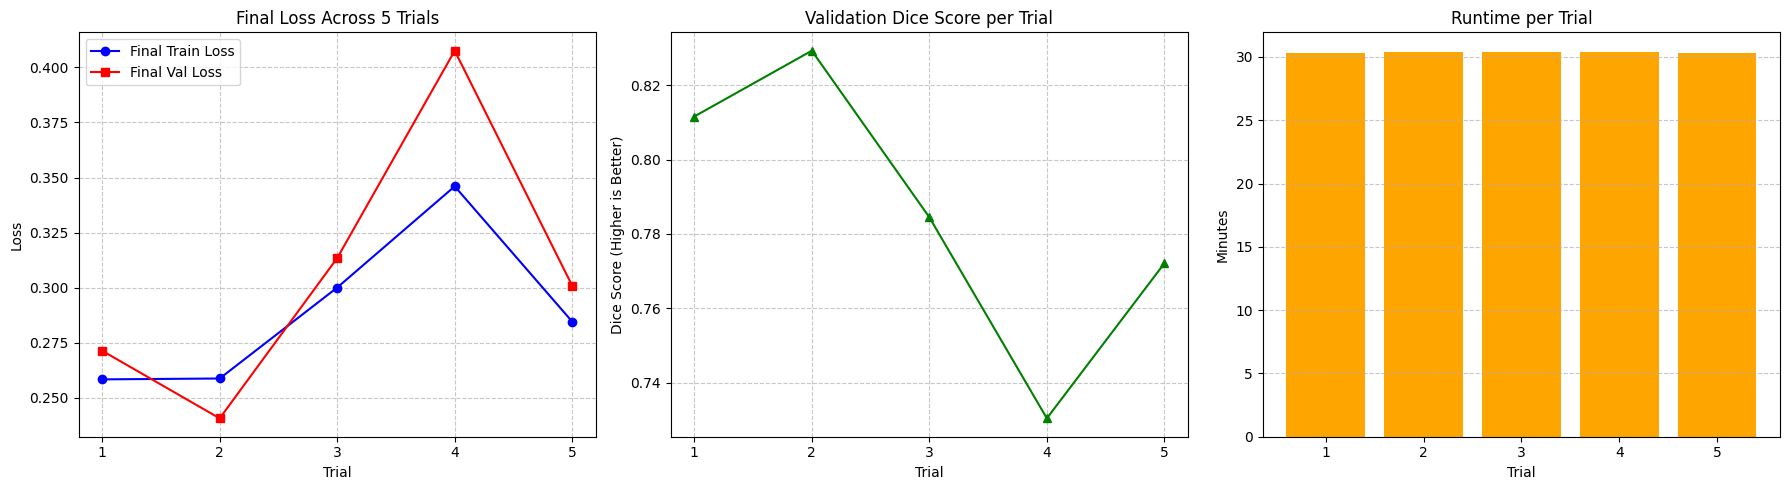

In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from tqdm import tqdm
import gc

# --- PUTTING THIS BACK JUST IN CASE IT GOT COMMENTED OUT ---
def dice_score(pred, target, threshold=0.5, smooth=1):
    pred = (pred > threshold).float()
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

# --- SETTINGS ---
NUM_TRIALS = 5
EPOCHS = 10

results = []

for trial in range(1, NUM_TRIALS + 1):
    print(f"\n" + "="*40)
    print(f"--- STARTING TRIAL {trial} ---")
    print("="*40)

    trial_start_time = time.time()

    # CRITICAL: Flush GPU memory before starting a new trial
    torch.cuda.empty_cache()
    gc.collect()

    # Re-initialize the model AND optimizer so it starts with a blank brain!
    model = UNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    train_losses, val_losses, val_dices = [], [], []
    total_train_batches = 0
    total_training_duration = 0.0

    for epoch in range(EPOCHS):
        # --- TRAINING ---
        model.train()
        train_loss = 0
        epoch_start_time = time.time()

        for imgs, masks in tqdm(train_loader, desc=f"Trial {trial} - Epoch {epoch+1}/{EPOCHS} [Train]"):
            imgs, masks = imgs.to(device), masks.to(device)

            optimizer.zero_grad()
            preds = model(imgs)
            loss = combined_loss(preds, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            total_train_batches += 1

        epoch_end_time = time.time()
        total_training_duration += (epoch_end_time - epoch_start_time)

        # --- VALIDATION ---
        model.eval()
        val_loss, val_dice = 0, 0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                preds = model(imgs)
                val_loss += combined_loss(preds, masks).item()
                val_dice += dice_score(preds, masks).item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        val_dice /= len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_dices.append(val_dice)
        print(f"Trial {trial} - Epoch {epoch+1}: Train={train_loss:.4f} | Val Loss={val_loss:.4f} | Val Dice={val_dice:.4f}")

    trial_end_time = time.time()

    # Extract Data for the Spreadsheet using the FINAL epoch
    runtime_mins = (trial_end_time - trial_start_time) / 60.0
    final_train_loss = train_losses[-1]
    final_val_loss = val_losses[-1]
    final_val_dice = val_dices[-1]
    avg_it_per_sec = total_train_batches / total_training_duration if total_training_duration > 0 else 0

    # Save trial data
    results.append({
        'Trial Number ->': trial,
        'Total Runtime (Mins)': round(runtime_mins, 2),
        'Avg Train Loss': round(final_train_loss, 4),
        'Avg Val Loss': round(final_val_loss, 4),
        'Avg Val Dice': round(final_val_dice, 4),
        'Avg iterations/sec': round(avg_it_per_sec, 2)
    })

# --- SPREADSHEET OUTPUT ---
df_results = pd.DataFrame(results)
print("\n" + "="*50)
print("FINAL SPREADSHEET DATA")
print("="*50)
print(df_results.to_string(index=False))

# --- POSTER GRAPHS ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(df_results['Trial Number ->'], df_results['Avg Train Loss'], marker='o', label='Final Train Loss', color='blue')
axes[0].plot(df_results['Trial Number ->'], df_results['Avg Val Loss'], marker='s', label='Final Val Loss', color='red')
axes[0].set_title('Final Loss Across 5 Trials')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Loss')
axes[0].set_xticks(df_results['Trial Number ->'])
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

axes[1].plot(df_results['Trial Number ->'], df_results['Avg Val Dice'], marker='^', color='green')
axes[1].set_title('Validation Dice Score per Trial')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('Dice Score (Higher is Better)')
axes[1].set_xticks(df_results['Trial Number ->'])
axes[1].grid(True, linestyle='--', alpha=0.7)

axes[2].bar(df_results['Trial Number ->'], df_results['Total Runtime (Mins)'], color='orange')
axes[2].set_title('Runtime per Trial')
axes[2].set_xlabel('Trial')
axes[2].set_ylabel('Minutes')
axes[2].set_xticks(df_results['Trial Number ->'])
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()